# AI Infrastructure Financial Network: Phase 0.5 Five-Company Pilot
### *The Bubble Lives in the Joins: Emerging Coordination Failures, Multi-Contract Graphs, and Shared Vulnerabilities in AI Infrastructure*

---

## Central Organizing Thesis

The thing that blows up in a financial bubble is often **not hidden data**. It is a **hidden relationship between data that everybody can see**.
* **Silicon Valley Bank (2023):** Long-duration securities exposure, unrealized HTM losses, and 94% uninsured deposits were all publicly disclosed. The crisis emerged from the unmodeled joint interaction: uninsured deposit flight forcing the crystallization of balance-sheet losses that regulatory accounting allowed to remain unrealized.
* **Archegos Capital Management (2021):** Each prime broker knew its individual loan exposure to Archegos. What none possessed was the aggregate graph: identical total-return swaps across multiple counterparties concentrating $160B of exposure on $36B of capital.
* **Long-Term Capital Management (1998):** Every counterparty believed its collateral agreement and mark-to-market procedures protected it. Collectively, they had enabled a massive correlated position.

### The Five Kinds of Opacity in 2020s AI Capital Structures
1. **Perimeter Opacity:** Risk is isolated in Special Purpose Vehicles (SPVs) or project-level subsidiaries rather than the consolidated parent balance sheet (e.g. CoreWeave SPV VIII and APLD ELN project LLCs).
2. **Network Opacity:** Participants see direct counterparty commitments, but none observe the aggregate dependence on identical customers, lenders, or suppliers (e.g. 67% of CoreWeave revenue tied to Microsoft).
3. **Contract Opacity:** Multi-billion dollar backlogs and lease agreements are announced, but termination remedies, liquidated damages, milestone triggers, and **unconditional springing guarantees** remain buried in Exhibit 10 agreements.
4. **Valuation Opacity:** Collateral (GPU clusters) is marked at historical cost or recent transaction prices, ignoring secondary liquidation value under simultaneous distress.
5. **Temporal Opacity:** Severe cash flow maturity mismatches: 5-year debt facilities funding 15-year lease obligations subject to 24–36 month utility substation lead times.

This notebook establishes **Phase 0.5** of the AI Infrastructure Financial Network across five core companies forming a closed capital, hardware, and lease chain: **NVIDIA (NVDA)**, **Supermicro (SMCI)**, **CoreWeave (CRWV)**, **Applied Digital (APLD)**, and **Oracle (ORCL)**, linked to strategic counterparties **Microsoft (MSFT)**, institutional bondholders, and private credit syndicates.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.graph import ObligationNetwork
from src.reachability import ContractualReachability
from src.stress import FinancialStressEngine

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Environment initialized successfully.")
print(f"Project Root: {project_root}")


Environment initialized successfully.
Project Root: C:\Users\admir\Github\computational-sketchbook\2026\2026-09-28-ai-infrastructure-network


## 1. Entity Registry & Scope of Pilot

We model the network across four functional tiers:
1. **Accelerated Silicon Supplier:** NVIDIA (`NVDA`)
2. **Server OEM / Integrator:** Supermicro (`SMCI`)
3. **Leveraged Neocloud Operator:** CoreWeave (`CRWV`) & Equipment SPV (`CRWV_SPV_VIII`)
4. **HPC Data Center Developer:** Applied Digital (`APLD`) & Facility SPV (`APLD_ELN_LLC`)
5. **Enterprise Cloud Hyperscaler:** Oracle (`ORCL`) & Off-take Anchor Microsoft (`MSFT`)
6. **Capital Providers & Infrastructure:** Private Credit Syndicate (`BLACKSTONE_MAGNETAR_SYN`), Institutional Bondholders, and Polaris Forge 1 Campus (`POLARIS_FORGE_1`)


In [2]:
entities_df = pd.read_parquet(project_root / "data/processed/entities.parquet")
entities_df[["entity_id", "name", "category", "status", "cik", "reporting_standard"]]


,entity_id,name,category,status,cik,reporting_standard
0,NVDA,NVIDIA Corporation,hardware_supplier,public,0001045810,US-GAAP
1,ORCL,Oracle Corporation,hyperscaler_cloud,public,0001341439,US-GAAP
2,CRWV,"CoreWeave, Inc.",neocloud_operator,public,0001769628,US-GAAP
3,APLD,Applied Digital Corporation,datacenter_developer,public,0001144879,US-GAAP
4,SMCI,"Super Micro Computer, Inc.",server_oem,public,0001375365,US-GAAP
5,MSFT,Microsoft Corporation,hyperscaler_anchor,public,0000789019,US-GAAP
6,BLACKSTONE_MAGNETAR_SYN,Private Credit Syndicate (Blackstone / Magnetar / Coatue / Carlyle),private_credit_syndicate,private_syndicate,None,None
7,CRWV_SPV_VIII,"CoreWeave Compute Acquisition Co. VIII, LLC",project_spv,subsidiary_spv,None,US-GAAP_consolidated
8,APLD_ELN_LLC,APLD ELN-02 LLC & ELN-03 LLC,project_spv,subsidiary_spv,None,US-GAAP_consolidated
9,POLARIS_FORGE_1,"Polaris Forge 1 Campus (Ellendale, North Dakota)",physical_asset_project,physical_asset,None,None


## 2. Layer 1: Audited Accounting Baselines (Direct SEC XBRL Ingestion)

We query `data.sec.gov` directly via `src/sec_ingest.py`, parsing standardized US-GAAP concepts from Form 10-K and 10-Q periodic filings.
Crucially, we distinguish **instant balance sheet facts** from **duration flow facts** (3-month quarterly vs 12-month annual), and aggregate funded debt components (long-term debt, current portion, convertible senior notes, and credit facilities) rather than relying on single unaggregated tags.


In [3]:
financials_df = pd.read_parquet(project_root / "data/processed/financials.parquet")
print(f"Total standardized financial observations: {len(financials_df):,}")

# Instant Balance Sheet Metrics (as of latest balance sheet date)
instant_df = (
    financials_df[financials_df["duration_type"] == "instant"]
    .sort_values(by=["entity_id", "metric", "period_end", "filed_date"])
    .groupby(["entity_id", "metric"])
    .last()
    .reset_index()
)
pivot_inst = instant_df.pivot(index="entity_id", columns="metric", values="value") / 1e9

# Flow Metrics (Quarterly Run-Rate / Annual Flows)
flow_df = (
    financials_df[financials_df["duration_type"].isin(["quarterly", "annual"])]
    .sort_values(by=["entity_id", "metric", "period_end", "filed_date"])
    .groupby(["entity_id", "metric"])
    .last()
    .reset_index()
)
pivot_flow = flow_df.pivot(index="entity_id", columns="metric", values="value") / 1e9

bs_summary = pd.DataFrame({
    "Cash & Equiv ($B)": pivot_inst.get("cash_and_equivalents", 0.0),
    "Total Debt ($B)": pivot_inst.get("total_debt", 0.0),
    "Lease Liabilities ($B)": pivot_inst.get("operating_lease_liabilities", 0.0),
    "PP&E Net ($B)": pivot_inst.get("ppe_net", 0.0),
    "Latest Rev Flow ($B)": pivot_flow.get("revenue", 0.0),
    "Latest OCF Flow ($B)": pivot_flow.get("operating_cash_flow", 0.0)
}).round(2).fillna(0.0)

bs_summary


Total standardized financial observations: 5,319


,Cash & Equiv ($B),Total Debt ($B),Lease Liabilities ($B),PP&E Net ($B),Latest Rev Flow ($B),Latest OCF Flow ($B)
entity_id,,,,,,
APLD,1.59,4.98,0.07,4.24,0.61,0.09
CRWV,5.52,35.55,16.32,46.74,2.58,2.98
MSFT,20.94,46.14,21.92,313.08,19.95,182.94
NVDA,22.44,33.37,5.49,14.28,96.22,50.34
ORCL,36.37,125.34,34.62,127.84,67.36,23.10
SMCI,7.52,8.72,0.54,0.63,0.68,-6.81


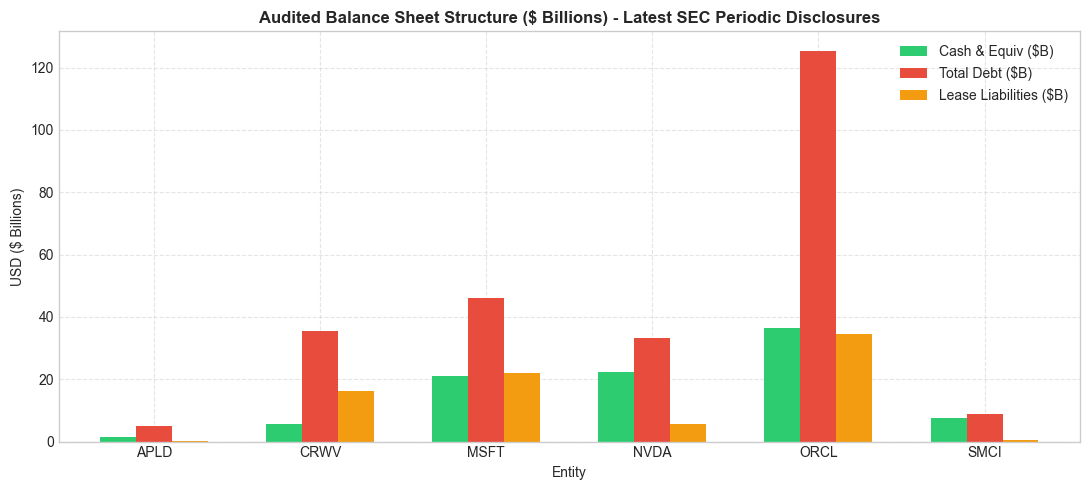

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
bs_plot = bs_summary[["Cash & Equiv ($B)", "Total Debt ($B)", "Lease Liabilities ($B)"]]
bs_plot.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c", "#f39c12"], width=0.65)
ax.set_title("Audited Balance Sheet Structure ($ Billions) - Latest SEC Periodic Disclosures", fontsize=12, fontweight="bold")
ax.set_ylabel("USD ($ Billions)")
ax.set_xlabel("Entity")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/fin_bs_structure.png", dpi=300)
plt.show()


## 3. Layer 2: The Contractual Obligation Multi-Graph

We model obligations using `nx.MultiDiGraph` with `obligation_id` as the edge key.
This architecture preserves multiple distinct facilities between the same counterparty pair (e.g. CoreWeave's distinct DDTLs, senior notes, convertibles, and lease + springing guarantee) without risk of overwrite.

Crucially, we **do not compute a naive net exposure** (netting a 15-year lease against a 2-year purchase commitment or equity stake). Instead, exposure is categorized strictly by **`amount_type`**.


In [5]:
net = ObligationNetwork()
exposure_df = net.compute_exposure_by_amount_type()

exposure_table = exposure_df.assign(
    principal_debt_B=lambda df: (df["outgoing_principal_debt_usd"] / 1e9).round(2),
    lease_lifetime_B=lambda df: (df["outgoing_lease_lifetime_usd"] / 1e9).round(2),
    purchase_commitments_B=lambda df: (df["outgoing_purchase_commitments_usd"] / 1e9).round(2),
    contingent_guarantee_B=lambda df: (df["outgoing_contingent_guarantees_usd"] / 1e9).round(2),
    equity_investment_B=lambda df: (df["outgoing_equity_investments_usd"] / 1e9).round(2)
)[["entity_id", "category", "principal_debt_B", "lease_lifetime_B", "purchase_commitments_B", "contingent_guarantee_B", "equity_investment_B"]]

exposure_table[exposure_table[["principal_debt_B", "lease_lifetime_B", "purchase_commitments_B", "contingent_guarantee_B", "equity_investment_B"]].sum(axis=1) > 0]


,entity_id,category,principal_debt_B,lease_lifetime_B,purchase_commitments_B,contingent_guarantee_B,equity_investment_B
2,CRWV,neocloud_operator,30.64,0.0,0.0,11.0,0.0
8,APLD_ELN_LLC,project_spv,4.96,0.0,0.0,0.0,0.0
4,SMCI,server_oem,0.00,0.0,34.2,0.0,0.0
0,NVDA,hardware_supplier,0.00,0.0,0.0,0.0,2.0
7,CRWV_SPV_VIII,project_spv,0.00,11.0,0.0,0.0,0.0


In [6]:
obl_df = pd.read_parquet(project_root / "data/processed/obligations.parquet")
obl_df[["obligation_id", "from_entity", "to_entity", "obligation_type", "amount", "amount_type", "as_of_date", "term_years", "recourse", "shared_assumptions"]].assign(
    amount_B=lambda df: (df["amount"] / 1e9).round(2)
).drop(columns=["amount"])


,obligation_id,from_entity,to_entity,obligation_type,amount_type,as_of_date,term_years,recourse,shared_assumptions,amount_B
0,OBL-CRWV-APLD-LEASE,CRWV_SPV_VIII,APLD_ELN_LLC,datacenter_lease,lifetime_contract_value,2026-05-31,15.0,limited_recourse_spv,"A002,A003,A004,A005",11.00
1,OBL-CRWV-APLD-GUARANTY,CRWV,APLD_ELN_LLC,contingent_guarantee,contingent_guarantee,2026-05-31,14.2,springing_parent_guaranty,"A002,A003,A005",11.00
2,OBL-CRWV-DEBT-DDTL,CRWV,BLACKSTONE_MAGNETAR_SYN,debt_facility,principal_outstanding,2026-06-30,5.0,limited_recourse_spv,"A001,A002,A005",10.81
3,OBL-CRWV-DEBT-NOTES,CRWV,INSTITUTIONAL_BONDHOLDERS,debt_facility,principal_outstanding,2026-06-30,6.5,full_recourse,A002,9.03
4,OBL-CRWV-DEBT-CONV,CRWV,INSTITUTIONAL_BONDHOLDERS,debt_facility,principal_outstanding,2026-06-30,6.5,full_recourse,A002,6.59
5,OBL-CRWV-DEBT-OEM,CRWV,OEM_FINANCING_PARTNERS,debt_facility,principal_outstanding,2026-06-30,4.0,full_recourse,"A001,A002",4.22
6,OBL-MSFT-CRWV-OFFTAKE,MSFT,CRWV,anchor_offtake,annualized_run_rate,2025-12-31,5.0,full_recourse,"A005,A006",1.72
7,OBL-SMCI-SUPPLIER-COMMIT,SMCI,HARDWARE_SUPPLIERS,gpu_procurement,remaining_commitment,2026-06-30,1.0,full_recourse,"A001,A006,A007",34.20
8,OBL-NVDA-CRWV-EQUITY,NVDA,CRWV,equity_investment,equity_investment,2026-01-31,NaN,equity_risk,A006,2.00
9,OBL-APLD-DEBT-PROJECT,APLD_ELN_LLC,PROJECT_LENDERS,debt_facility,principal_outstanding,2026-05-31,5.0,limited_recourse_spv,"A002,A004",4.96


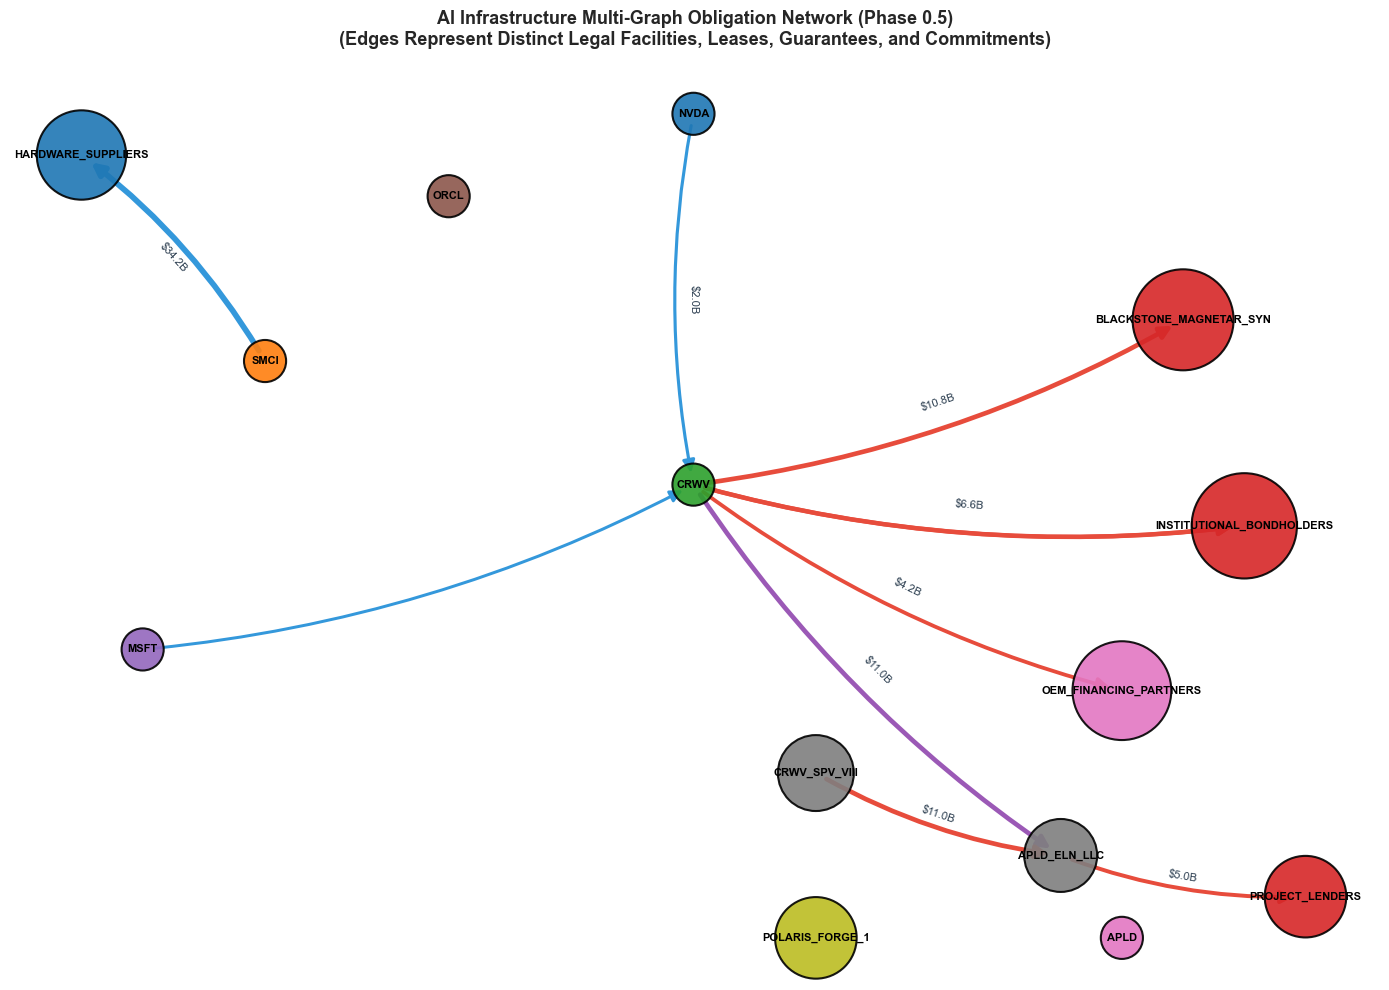

In [7]:
G = net.graph

plt.figure(figsize=(14, 10))
pos = {
    "NVDA": np.array([0.0, 1.0]),
    "SMCI": np.array([-0.7, 0.4]),
    "HARDWARE_SUPPLIERS": np.array([-1.0, 0.9]),
    "CRWV": np.array([0.0, 0.1]),
    "MSFT": np.array([-0.9, -0.3]),
    "BLACKSTONE_MAGNETAR_SYN": np.array([0.8, 0.5]),
    "INSTITUTIONAL_BONDHOLDERS": np.array([0.9, 0.0]),
    "OEM_FINANCING_PARTNERS": np.array([0.7, -0.4]),
    "CRWV_SPV_VIII": np.array([0.2, -0.6]),
    "APLD_ELN_LLC": np.array([0.6, -0.8]),
    "PROJECT_LENDERS": np.array([1.0, -0.9]),
    "POLARIS_FORGE_1": np.array([0.2, -1.0]),
    "APLD": np.array([0.7, -1.0]),
    "ORCL": np.array([-0.4, 0.8])
}

category_colors = {
    "hardware_supplier": "#1f77b4",
    "server_oem": "#ff7f0e",
    "neocloud_operator": "#2ca02c",
    "hyperscaler_anchor": "#9467bd",
    "hyperscaler_cloud": "#8c564b",
    "private_credit_syndicate": "#d62728",
    "capital_markets": "#d62728",
    "hardware_financing": "#e377c2",
    "datacenter_developer": "#e377c2",
    "project_spv": "#7f7f7f",
    "physical_asset_project": "#bcbd22"
}

node_colors = [category_colors.get(G.nodes[n].get("category", ""), "#333333") for n in G.nodes()]
node_sizes = [max(900, len(n) * 230) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", font_family="sans-serif")

# Draw edges
for u, v, k, d in G.edges(data=True, keys=True):
    amt = d.get("amount", 1e9)
    width = max(1.2, np.log10(amt) - 7.8) * 1.5
    edge_color = "#e74c3c" if "DEBT" in k or "LEASE" in k else ("#9b59b6" if "GUARANTY" in k else "#3498db")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], width=width, edge_color=edge_color,
        arrowsize=18, arrowstyle="-|>", connectionstyle="arc3,rad=0.1"
    )

edge_labels = {(u, v): f"${d.get('amount', 0)/1e9:.1f}B" for u, v, k, d in G.edges(data=True, keys=True) if d.get("amount", 0) >= 2e9}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="#2c3e50")

plt.title("AI Infrastructure Multi-Graph Obligation Network (Phase 0.5)\n(Edges Represent Distinct Legal Facilities, Leases, Guarantees, and Commitments)", fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/obligation_network_topology.png", dpi=300)
plt.show()


## 4. Unwrapping Perimeter Opacity: The Springing Guaranty

Notice the structural legal architecture revealed in APLD's Form 10-K (Note 14):
* CoreWeave assigned its direct lease liabilities for Polaris Forge 1 to `CRWV_SPV_VIII` and was released from direct lease obligations.
* **HOWEVER**, CoreWeave concurrently executed an **Unconditional Springing Guaranty of Payment and Performance** for the SPV's obligations.
* Thus, perimeter isolation does NOT eliminate parent corporate risk; it creates a **contingent liquidity cliff** that springs back to the parent if the SPV's cash flows falter!


In [8]:
collapsed_graph = net.unwrap_spv_perimeter()
print(f"Consolidated Economic Network: {collapsed_graph.number_of_nodes()} Nodes | {collapsed_graph.number_of_edges()} Edges")

collapsed_records = []
for u, v, k, d in collapsed_graph.edges(data=True, keys=True):
    collapsed_records.append({
        "from_parent": u,
        "to_parent": v,
        "obligation_key": k,
        "amount_B": round(d.get("amount", 0.0) / 1e9, 2),
        "amount_type": d.get("amount_type"),
        "primary_type": d.get("primary_type"),
        "recourse": d.get("recourse")
    })
pd.DataFrame(collapsed_records).sort_values(by="amount_B", ascending=False)


Consolidated Economic Network: 10 Nodes | 10 Edges


,from_parent,to_parent,obligation_key,amount_B,amount_type,primary_type,recourse
8,SMCI,HARDWARE_SUPPLIERS,OBL-SMCI-SUPPLIER-COMMIT,34.20,remaining_commitment,gpu_procurement,full_recourse
1,CRWV,APLD,OBL-CRWV-APLD-GUARANTY,11.00,contingent_guarantee,contingent_guarantee,springing_parent_guaranty
2,CRWV,APLD,OBL-CRWV-APLD-LEASE,11.00,lifetime_contract_value,datacenter_lease,limited_recourse_spv
3,CRWV,BLACKSTONE_MAGNETAR_SYN,OBL-CRWV-DEBT-DDTL,10.81,principal_outstanding,debt_facility,limited_recourse_spv
4,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-NOTES,9.03,principal_outstanding,debt_facility,full_recourse
5,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-CONV,6.59,principal_outstanding,debt_facility,full_recourse
7,APLD,PROJECT_LENDERS,OBL-APLD-DEBT-PROJECT,4.96,principal_outstanding,debt_facility,limited_recourse_spv
6,CRWV,OEM_FINANCING_PARTNERS,OBL-CRWV-DEBT-OEM,4.22,principal_outstanding,debt_facility,full_recourse
0,NVDA,CRWV,OBL-NVDA-CRWV-EQUITY,2.00,equity_investment,equity_investment,equity_risk
9,MSFT,CRWV,OBL-MSFT-CRWV-OFFTAKE,1.73,annualized_run_rate,anchor_offtake,full_recourse


## 5. Topological Reachability vs. True Financial Stress

We explicitly separate two analytical concepts:
1. **Assumption Dependency Footprint (Reachability):** What proportion of the network's face value and edges are reachable within 1 or 2 hops of an underlying economic assumption? (Topological exposure metric).
2. **Financial Stress Engine:** A quantitative transmission simulation modeling cash flow losses, collateral haircuts, borrowing base contractions, and liquidity depletion.


In [9]:
reach_engine = ContractualReachability(network=net)
reach_summary = reach_engine.run_standard_footprints()

reach_display = reach_summary.assign(
    total_reachable_value_B=lambda df: (df["total_reachable_value_usd"] / 1e9).round(2)
)[["scenario_id", "assumptions", "total_reachable_edges", "edge_reachability_pct", "total_reachable_value_B", "value_reachability_pct"]]
reach_display


,scenario_id,assumptions,total_reachable_edges,edge_reachability_pct,total_reachable_value_B,value_reachability_pct
0,REACH_A006_CAPEX_EXPANSION,A006,9,90.0,90.57,94.8
1,REACH_A001_GPU_RESIDUAL_VALUE,A001,7,70.0,86.84,90.9
2,REACH_A005_ANCHOR_CUSTOMER,A005,8,80.0,59.33,62.1
3,REACH_A002_REFINANCING,A002,7,70.0,57.60,60.3
5,REACH_A003_UTILIZATION,A003,7,70.0,57.60,60.3
4,REACH_A004_POWER_DELIVERY,A004,2,20.0,15.96,16.7


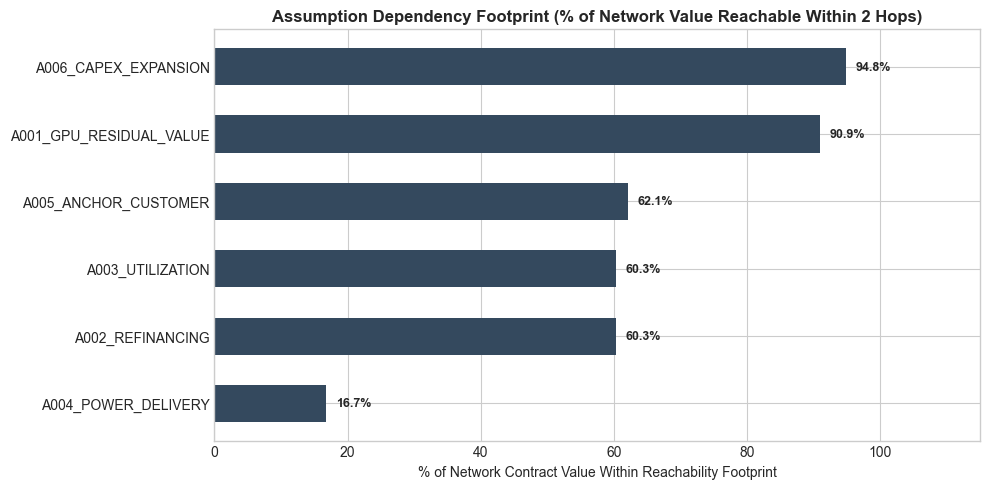

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
reach_plot = reach_summary.sort_values(by="value_reachability_pct", ascending=True)
bars = ax.barh(reach_plot["scenario_id"].str.replace("REACH_", ""), reach_plot["value_reachability_pct"], color="#34495e", height=0.55)
ax.set_title("Assumption Dependency Footprint (% of Network Value Reachable Within 2 Hops)", fontsize=12, fontweight="bold")
ax.set_xlabel("% of Network Contract Value Within Reachability Footprint")
ax.set_xlim(0, 115)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/assumption_reachability_footprint.png", dpi=300)
plt.show()


## 6. Financial Stress & Transmission Engine

Using `src/stress.py`, we execute quantitative mathematical simulations:
$$	ext{Shock} \longrightarrow \Delta 	ext{ Cash Flow} \longrightarrow 	ext{Collateral / Covenant Breach} \longrightarrow 	ext{Liquidity Cure} \longrightarrow 	ext{Next Edge}$$

We test five adversarial scenarios:
1. **GPU Collateral Valuation Haircut (-40%):** Evaluates borrowing base contraction on CoreWeave's $10.8B DDTLs, computes mandatory prepayment call against CoreWeave's $5.52B cash.
2. **Anchor Customer Demand Trim (-30%):** Reduces CoreWeave recognized revenue by $518M/yr, testing debt service coverage and springing guaranty activation on the $11.0B lease.
3. **Refinancing Spread Spike (+300 bps):** Computes $473M annual floating interest expansion across CoreWeave and Applied Digital.
4. **Grid Substation Energization Delay (12 Months):** Defers $733M in rent to Applied Digital while construction debt carrying costs run ($397M drain on $1.59B cash).
5. **Hardware OEM Purchase Commitment Markdown (15%):** Tests Supermicro's $34.2B purchase commitments, forcing a $5.13B write-down against $7.52B cash reserves.


In [11]:
stress_engine = FinancialStressEngine(network=net)
stress_summary = stress_engine.run_all_stress_scenarios()

stress_display = stress_summary.assign(
    direct_hit_B=lambda df: (df["direct_cash_or_collateral_hit_usd"] / 1e9).round(2)
)[["scenario_name", "shock_parameter", "target_entity", "direct_hit_B", "covenant_or_liquidity_impact", "contagion_mechanism"]]
stress_display


,scenario_name,shock_parameter,target_entity,direct_hit_B,covenant_or_liquidity_impact,contagion_mechanism
0,GPU Collateral Valuation Haircut,-40% GPU Resale Value,CRWV,4.32,78.2% Cash Depletion,"Forces $4.32B debt prepayment, exhausting operational capex."
1,Anchor Customer Demand Trim,-30% Microsoft Off-Take,CRWV,0.52,Activates Springing Guaranty,"Reduces annual cash flow by $518M, triggering $11B lease parent guarantee."
2,Credit Refinancing Spread Spike,+300 bps Refinancing Spread,CRWV / APLD,0.47,Cash Squeeze,Adds $473M annual interest across CoreWeave and Applied Digital.
3,Grid Substation Energization Delay,12-Month Grid Delay,APLD,0.40,24.9% Cash Drain,Defers $733M lease rent while carrying $397M debt carrying cost.
4,Hardware OEM Purchase Commitment Markdown,15% Hardware Demand Pause,SMCI,5.13,68.2% Cash Depletion,Triggers $5.13B write-down on $34.2B purchase commitments.


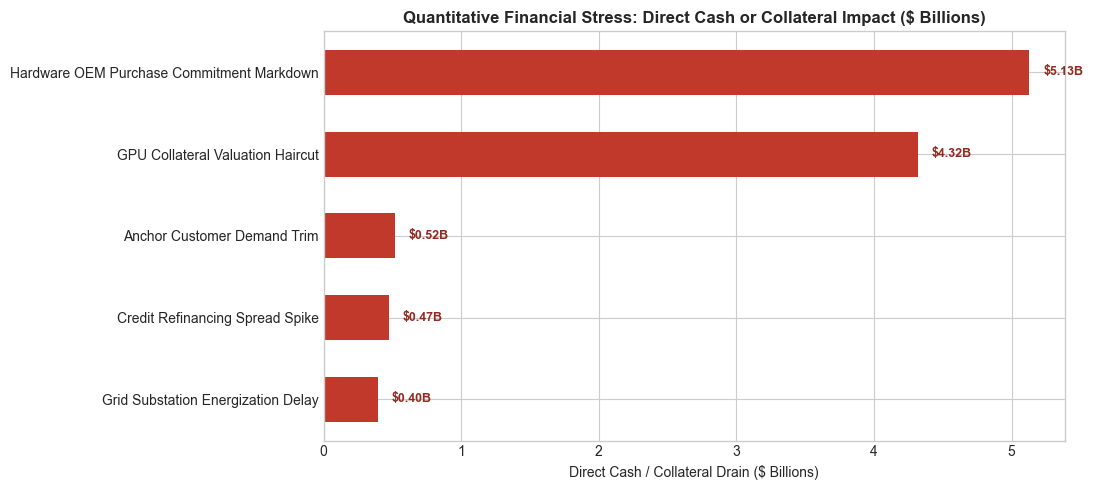

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
stress_plot = stress_summary.sort_values(by="direct_cash_or_collateral_hit_usd", ascending=True)
bars = ax.barh(stress_plot["scenario_name"], stress_plot["direct_cash_or_collateral_hit_usd"] / 1e9, color="#c0392b", height=0.55)
ax.set_title("Quantitative Financial Stress: Direct Cash or Collateral Impact ($ Billions)", fontsize=12, fontweight="bold")
ax.set_xlabel("Direct Cash / Collateral Drain ($ Billions)")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.1, bar.get_y() + bar.get_height()/2, f"${w:.2f}B", va="center", fontsize=9, fontweight="bold", color="#922b21")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/financial_stress_waterfall.png", dpi=300)
plt.show()


## 7. Verifiable Evidence Ledger (Audit Receipts)

Every contractual assertion in this notebook is backed by an audited SEC EDGAR citation in `data/processed/evidence_claims.parquet`.
Below are the exact verbatim excerpts and accession numbers proving the $11.0B Polaris Forge lease, the $35.551B debt structure, the SPV springing guaranty, the $34.2B SMCI commitments, and the 67% Microsoft concentration.


In [13]:
claims_df = pd.read_parquet(project_root / "data/processed/evidence_claims.parquet")
claims_df[["claim_id", "entity_id", "filing_type", "filing_date", "section_locator", "exact_quote", "evidence_class"]]


,claim_id,entity_id,filing_type,filing_date,section_locator,exact_quote,evidence_class
0,CLM-APLD-001,APLD,10-K,2026-07-29,Item 1. Business - Data Center Leases,"On May 28, 2025, our subsidiaries APLD ELN-02 LLC and APLD ELN-03 LLC each entered into a data center lease (the 'EL...",A
1,CLM-APLD-002,APLD,10-K,2026-07-29,Note 14. Commitments and Contingencies - Data Center Leases,"On March 30, 2026, CoreWeave entered into an Assignment, Assumption and Consent Agreement with CoreWeave SPV and APL...",A
2,CLM-CRWV-001,CRWV,10-Q,2026-08-12,Note 7. Debt - Debt Principal Maturities Table,"Years Ending December 31, Amount: Remaining portion of 2026: $4,413; 2027: $6,184; 2028: $4,416; 2029: $2,421; 2030:...",A
3,CLM-CRWV-002,CRWV,10-Q,2026-08-12,Note 7. Debt - Credit Facilities and Term Loans,"DDTL 1.0 Facility Mar 2028: $1,300; DDTL 2.0 Facility Aug 2030: $3,190; DDTL 2.1 Facility Mar 2031: $3,000; DDTL 3.0...",A
4,CLM-CRWV-003,CRWV,10-K,2026-03-02,Note 17. Customer Concentration and Segment Disclosures,A substantial portion of our revenue is driven by a limited number of customers. We recognized an aggregate of appro...,A
5,CLM-SMCI-001,SMCI,10-K,2026-08-31,Note 12. Commitments and Contingencies - Purchase Commitments,Purchase Commitments - We have agreements to purchase inventory and non-inventory items primarily through the next 1...,A
6,CLM-NVDA-CRWV-001,CRWV,10-Q,2026-05-08,Note 10. Stockholders' Equity - January 2026 Private Placement,"In January 2026, we completed a private placement financing with NVIDIA Corporation, issuing shares of Series C Conv...",A
7,CLM-ORCL-001,ORCL,10-K,2026-06-25,Item 7. MD&A - Cloud Infrastructure and Hardware Financing,"For certain large-scale artificial intelligence cloud customer contracts, customers either prepay for dedicated grap...",A


## 8. Synthesis & Computational Sketchbook Findings

### What Phase 0.5 Established
1. **The Bubble Lives in the Joins:** On consolidated statements, Applied Digital appears as a standalone host with $1.59B in cash and $4.98B in debt. But through the join at Polaris Forge 1 ($11.0B 15-year lease with CoreWeave), APLD's cash flows are tied to CoreWeave's solvency.
2. **Perimeter Opacity & The Springing Guaranty:** CoreWeave did not simply dump lease obligations into an isolated SPV; it provided an **Unconditional Springing Guaranty of Payment and Performance**, creating a contingent liquidity cliff back to the parent.
3. **Decomposed Debt Realities:** CoreWeave's indebtedness is not a monolithic loan, but $35.551B in future principal across DDTLs ($10.8B), senior notes ($9.0B), convertible debt ($6.6B), and OEM financing ($4.2B).
4. **Mathematical Transmission:** A -40% GPU collateral haircut triggers a **$4.32B mandatory debt prepayment**, consuming 78.2% of CoreWeave's cash and forcing operational capex freezes down the supply chain.

### Next Steps for Phase 1
* Expand the entity universe from 5 pilot companies to 25–30 public and private players across upstream silicon (TSMC, ASML), power utilities (GE Vernova, Constellation), and private credit syndicates.
* Incorporate FINRA TRACE secondary bond prices to observe real-time market-implied credit spreads.
